# Generación, limpieza y transformación de un DataSet — El principio GIGO

**Fecha:** 28 de mayo del 2026  
**Autor:** Maria Reina Zarate Nava

## Objetivo general
Identificar problemas de calidad de datos, aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning
mediante el principio GIGO.

## Actividad
Identificar y documentar:
- Valores nulos
- Outliers (negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas (identificadas con la letra C)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:
- Limpiar el dataset
- Transformar los datos
- Justificar las decisiones tomadas
- Explicar cómo afecta el principio GIGO al análisis de datos y Machine Learning

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset

In [2]:
# Cargamos el dataset sucio de facturas
dfSucio = pd.read_csv("ventas-por-factura.csv")

In [3]:
# Dimensiones del dataset
dfSucio.shape

(25953, 6)

In [4]:
# Primeras filas
dfSucio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [6]:
# Tipos de datos originales
dfSucio.dtypes

N° de factura        object
Fecha de factura     object
ID Cliente          float64
País                 object
Cantidad              int64
Monto                object
dtype: object

## 3. Identificación de problemas de calidad

### 3.1 Valores nulos

In [7]:
# Conteo de valores nulos por columna
dfSucio.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [8]:
# Porcentaje de nulos por columna
(dfSucio.isnull().sum() / len(dfSucio)) * 100

N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64

### 3.2 Facturas canceladas (identificadas con 'C')

In [9]:
# Facturas canceladas — identificadas porque el número empieza con 'C'
facturas_canceladas = dfSucio[dfSucio["N° de factura"].astype(str).str.startswith("C")]
print(f"Total de facturas canceladas: {len(facturas_canceladas)}")
facturas_canceladas.head()

Total de facturas canceladas: 3841


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"


### 3.3 Duplicados

In [10]:
# Filas duplicadas
duplicados = dfSucio[dfSucio.duplicated()]
print(f"Total de filas duplicadas: {len(duplicados)}")
duplicados

Total de filas duplicadas: 10


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
7626,568403,9/27/2021 10:35:00,NaN,United Kingdom,-3,"0,00"
9728,C581390,12/8/2021 13:13:00,13081.0,United Kingdom,-13,"-15,85"
11263,568417,9/27/2021 11:10:00,14911.0,EIRE,202,"776,30"
12533,C581384,12/8/2021 13:06:00,17673.0,United Kingdom,-2,"-6,90"
13011,568423,9/27/2021 11:24:00,17061.0,United Kingdom,118,"573,40"
13054,568387,9/27/2021 10:04:00,13704.0,United Kingdom,340,"422,32"
15861,568384,9/27/2021 9:46:00,12748.0,United Kingdom,1,"0,00"
18795,C581323,12/8/2021 11:53:00,14442.0,Channel Islands,-1,"-4,25"
22578,C581330,12/8/2021 11:57:00,15877.0,United Kingdom,-125,"-52,50"
25704,568404,9/27/2021 10:36:00,NaN,United Kingdom,-17,"0,00"


### 3.4 Problemas de formato — Monto

In [11]:
# El campo Monto está como string con coma decimal (ej: '229,33')
# Necesita convertirse a float para poder operar con él
print("Tipo actual de Monto:", dfSucio["Monto"].dtype)
print()
print("Ejemplos de valores en Monto:")
dfSucio["Monto"].head(10)

Tipo actual de Monto: object

Ejemplos de valores en Monto:


0    229,33
1    209,73
2     -1,45
3     39,95
4    344,83
5    199,98
6     30,00
7     77,28
8     67,50
9    321,35
Name: Monto, dtype: object

### 3.5 Problemas de formato — Fecha

In [12]:
# La fecha viene como string con hora incluida (ej: '3/30/2021 16:14:00')
# Debe convertirse a tipo datetime
print("Tipo actual de Fecha:", dfSucio["Fecha de factura"].dtype)
print()
dfSucio["Fecha de factura"].head(5)

Tipo actual de Fecha: object



0     3/30/2021 16:14:00
1    11/11/2021 11:11:00
2    10/12/2021 11:32:00
3      4/6/2021 12:08:00
4    10/27/2021 15:33:00
Name: Fecha de factura, dtype: object

### 3.6 Outliers y valores negativos en Monto y Cantidad

In [13]:
# Convertimos temporalmente para explorar
monto_temp = dfSucio["Monto"].str.replace(",", ".").astype(float)

print("Estadísticas del Monto:")
print(monto_temp.describe())
print()
print(f"Montos negativos:  {(monto_temp < 0).sum()}")
print(f"Montos igual a 0:  {(monto_temp == 0).sum()}")
print()
print("Estadísticas de Cantidad:")
print(dfSucio["Cantidad"].describe())
print()
print(f"Cantidades negativas: {(dfSucio['Cantidad'] < 0).sum()}")
print(f"Cantidades igual a 0: {(dfSucio['Cantidad'] == 0).sum()}")

Estadísticas del Monto:
count     25953.000000
mean        375.657552
std        2009.042459
min     -168469.600000
25%          11.550000
50%         207.050000
75%         408.660000
max      168469.600000
Name: Monto, dtype: float64

Montos negativos:  3843
Montos igual a 0:  2105

Estadísticas de Cantidad:
count    25953.000000
mean       199.474049
std       1107.075809
min     -80995.000000
25%          6.000000
50%        100.000000
75%        240.000000
max      80995.000000
Name: Cantidad, dtype: float64

Cantidades negativas: 5179
Cantidades igual a 0: 0


## 4. Gráficas para identificación de anomalías
Las tres gráficas solicitadas: ventas por país, heatmap de nulos y distribución del monto.

### 4.1 Ventas por país

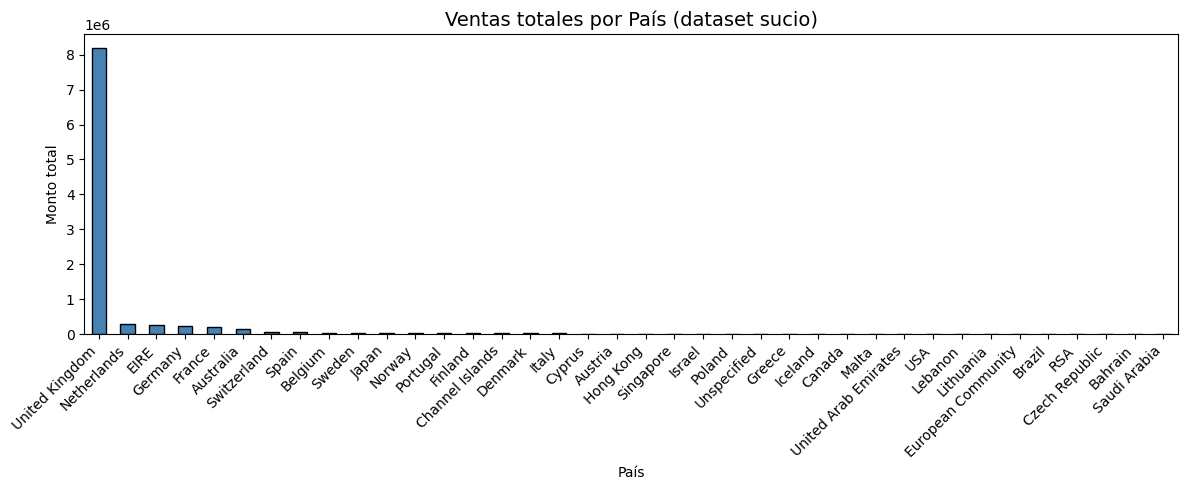

In [14]:
# Usamos el monto temporal para la gráfica exploratoria
monto_temp = dfSucio["Monto"].str.replace(",", ".").astype(float)
dfSucio["Monto_temp"] = monto_temp

ventas_pais = dfSucio.groupby("País")["Monto_temp"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ventas_pais.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Ventas totales por País (dataset sucio)", fontsize=14)
plt.xlabel("País")
plt.ylabel("Monto total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.2 Heatmap de valores nulos

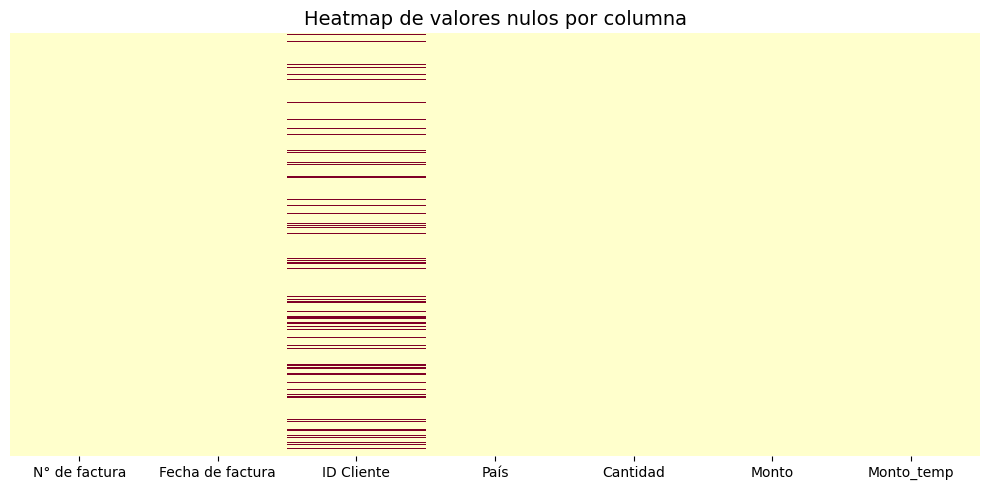

Nulos por columna:
N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
Monto_temp             0
dtype: int64


In [15]:
plt.figure(figsize=(10, 5))
sns.heatmap(dfSucio.isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd")
plt.title("Heatmap de valores nulos por columna", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen numérico
print("Nulos por columna:")
print(dfSucio.isnull().sum())

### 4.3 Distribución del Monto

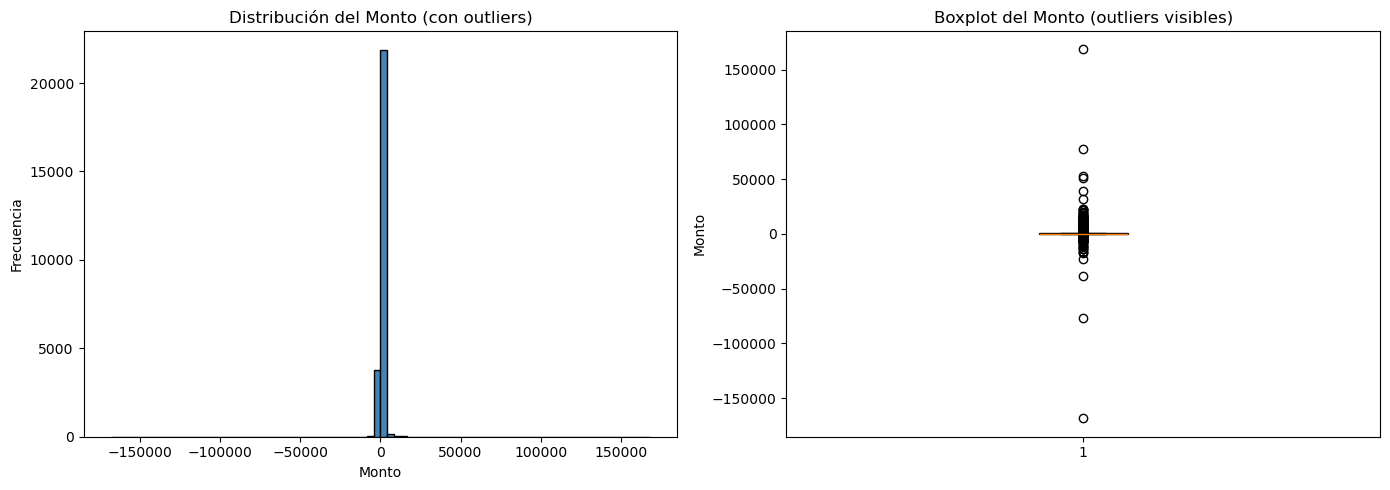

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(dfSucio["Monto_temp"].dropna(), bins=80, color="steelblue",
             edgecolor="black")
axes[0].set_title("Distribución del Monto (con outliers)")
axes[0].set_xlabel("Monto")
axes[0].set_ylabel("Frecuencia")

# Boxplot para visualizar outliers
axes[1].boxplot(dfSucio["Monto_temp"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[1].set_title("Boxplot del Monto (outliers visibles)")
axes[1].set_ylabel("Monto")

plt.tight_layout()
plt.show()

## 5. Limpieza del dataset

### 5.1 Eliminar columna temporal de exploración

In [17]:
# Eliminamos la columna temporal que usamos solo para explorar
dfSucio.drop(columns=["Monto_temp"], inplace=True)
print("Columna temporal eliminada.")

Columna temporal eliminada.


### 5.2 Eliminar duplicados

In [18]:
# Eliminamos filas completamente duplicadas
# Justificación: registrar dos veces la misma factura infla el total de ventas
dfSucio.drop_duplicates(inplace=True)
print(f"Filas después de eliminar duplicados: {dfSucio.shape[0]}")

Filas después de eliminar duplicados: 25943


### 5.3 Eliminar facturas canceladas

In [19]:
# Las facturas con 'C' son canceladas — no representan ingresos reales
# Justificación: incluirlas en el análisis distorsionaría totales y promedios
dfSucio = dfSucio[~dfSucio["N° de factura"].astype(str).str.startswith("C")]
print(f"Filas después de eliminar facturas canceladas: {dfSucio.shape[0]}")

Filas después de eliminar facturas canceladas: 22106


### 5.4 Eliminar cantidades inválidas (≤ 0)

In [20]:
# Cantidad negativa o cero no tiene sentido en una factura de venta válida
# Justificación: cantidades <= 0 corresponden a devoluciones o errores de captura
dfSucio = dfSucio[dfSucio["Cantidad"] > 0]
print(f"Filas después de eliminar cantidades inválidas: {dfSucio.shape[0]}")

Filas después de eliminar cantidades inválidas: 20770


### 5.5 Tratar valores nulos en ID Cliente

In [21]:
# ID Cliente tiene nulos — los rellenamos con 0 para indicar 'cliente desconocido'
# Justificación: no podemos inferir el ID, pero tampoco conviene eliminar la venta
print(f"Nulos en ID Cliente antes: {dfSucio['ID Cliente'].isnull().sum()}")
dfSucio["ID Cliente"] = dfSucio["ID Cliente"].fillna(0).astype(int)
print(f"Nulos en ID Cliente después: {dfSucio['ID Cliente'].isnull().sum()}")

Nulos en ID Cliente antes: 2204
Nulos en ID Cliente después: 0


## 6. Transformación de datos

### 6.1 Convertir Monto de string a float

In [22]:
# El monto usa coma como separador decimal (formato europeo)
# Lo reemplazamos por punto para que Python lo interprete correctamente
dfSucio["Monto"] = dfSucio["Monto"].str.replace(",", ".").astype(float)
print("Tipo de Monto después de transformar:", dfSucio["Monto"].dtype)
dfSucio["Monto"].describe()

Tipo de Monto después de transformar: float64


count     20770.000000
mean        512.496891
std        1748.961783
min      -11062.060000
25%         137.912500
50%         298.360000
75%         481.440000
max      168469.600000
Name: Monto, dtype: float64

### 6.2 Eliminar montos negativos

In [23]:
# Después de limpiar canceladas, aún pueden quedar montos negativos residuales
# Justificación: un monto negativo en una factura válida es un error de captura
print(f"Montos negativos antes: {(dfSucio['Monto'] < 0).sum()}")
dfSucio = dfSucio[dfSucio["Monto"] >= 0]
print(f"Montos negativos después: {(dfSucio['Monto'] < 0).sum()}")
print(f"Filas restantes: {dfSucio.shape[0]}")

Montos negativos antes: 2
Montos negativos después: 0
Filas restantes: 20768


### 6.3 Tratar outliers en Monto con IQR

In [24]:
# Calculamos los límites con el método IQR
Q1 = dfSucio["Monto"].quantile(0.25)
Q3 = dfSucio["Monto"].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print()

outliers = dfSucio[(dfSucio["Monto"] > limite_superior) | (dfSucio["Monto"] < limite_inferior)]
print(f"Outliers detectados: {len(outliers)}")

# Los reemplazamos con el límite (winsorización) en lugar de eliminarlos
# Justificación: conservamos las filas pero neutralizamos el efecto extremo
dfSucio["Monto"] = dfSucio["Monto"].clip(lower=limite_inferior, upper=limite_superior)
print("Outliers tratados con winsorización (clip).")

Q1: 137.95 | Q3: 481.45 | IQR: 343.50
Límite inferior: -377.30
Límite superior: 996.71

Outliers detectados: 1849
Outliers tratados con winsorización (clip).


### 6.4 Convertir Fecha a datetime y extraer componentes

In [25]:
# Convertimos a datetime para poder operar con la fecha
dfSucio["Fecha de factura"] = pd.to_datetime(dfSucio["Fecha de factura"])

# Extraemos año y mes como columnas adicionales (útiles para análisis temporal)
dfSucio["Año"] = dfSucio["Fecha de factura"].dt.year
dfSucio["Mes"] = dfSucio["Fecha de factura"].dt.month

print("Tipo de Fecha después:", dfSucio["Fecha de factura"].dtype)
dfSucio[["Fecha de factura", "Año", "Mes"]].head()

Tipo de Fecha después: datetime64[ns]


,Fecha de factura,Año,Mes
0,2021-03-30 16:14:00,2021,3
1,2021-11-11 11:11:00,2021,11
3,2021-04-06 12:08:00,2021,4
4,2021-10-27 15:33:00,2021,10
5,2021-11-16 08:38:00,2021,11


## 7. Verificación del dataset limpio

In [26]:
# Revisamos que no queden nulos
print("Nulos por columna después de limpieza:")
print(dfSucio.isnull().sum())

Nulos por columna después de limpieza:
N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
Año                 0
Mes                 0
dtype: int64


In [27]:
# Tipos de datos finales
dfSucio.dtypes

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                   int64
País                        object
Cantidad                     int64
Monto                      float64
Año                          int32
Mes                          int32
dtype: object

In [28]:
# Estadísticas finales del dataset limpio
dfSucio.describe()

,Fecha de factura,ID Cliente,Cantidad,Monto,Año,Mes
count,20768,20768.000000,20768.000000,20768.000000,20768.000000,20768.000000
mean,2021-06-29 03:53:08.098035200,13647.469857,272.581809,355.590044,2020.921514,7.379671
min,2020-12-01 08:26:00,0.000000,1.000000,0.000000,2020.000000,1.000000
25%,2021-03-28 15:05:15,13195.500000,63.000000,137.950000,2021.000000,5.000000
50%,2021-07-07 14:09:30,14871.000000,145.000000,298.380000,2021.000000,8.000000
75%,2021-10-11 08:38:45,16633.000000,288.000000,481.452500,2021.000000,11.000000
max,2021-12-09 12:50:00,18287.000000,80995.000000,996.706250,2021.000000,12.000000
std,NaN,4977.894393,942.919198,290.078597,0.268942,3.449037


In [29]:
# Vista previa del dataset limpio
dfSucio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes
0,548370,2021-03-30 16:14:00,15528,United Kingdom,123,229.33,2021,3
1,575767,2021-11-11 11:11:00,17348,United Kingdom,163,209.73,2021,11
3,549106,2021-04-06 12:08:00,17045,United Kingdom,1,39.95,2021,4
4,573112,2021-10-27 15:33:00,16416,United Kingdom,357,344.83,2021,10
5,576630,2021-11-16 08:38:00,13816,Germany,91,199.98,2021,11


## 8. Exportar dataset limpio

In [30]:
# Exportamos el dataset limpio a CSV
dfSucio.to_csv("Data_Limpio_Factura.csv", index=False)
print("Dataset exportado como: Data_Limpio_Factura.csv")
print(f"Shape final: {dfSucio.shape}")

Dataset exportado como: Data_Limpio_Factura.csv
Shape final: (20768, 8)


## 9. El principio GIGO y su impacto en Machine Learning

**GIGO** (*Garbage In, Garbage Out*) establece que si alimentamos un modelo o análisis
con datos de mala calidad, los resultados serán igualmente deficientes sin importar
la sofisticación del algoritmo utilizado.

En este dataset encontramos los siguientes problemas y su impacto potencial:

| Problema detectado | Impacto en ML / Análisis |
|---|---|
| **Facturas canceladas (3,841 registros)** | Inflan el total de ventas; un modelo de predicción de ingresos aprendería patrones incorrectos |
| **Montos negativos** | Distorsionan la media y desviación estándar; afectan modelos de regresión |
| **Cantidad = 0 o negativa** | Un modelo de demanda aprendería que ciertos productos tienen demanda nula o negativa |
| **Monto como string con coma** | Sin conversión, cualquier operación aritmética falla por completo |
| **ID Cliente nulo (3,724 registros)** | Imposibilita análisis de comportamiento por cliente o segmentación |
| **Duplicados (10 registros)** | Sesgan el peso de ciertos registros en el entrenamiento |
| **Outliers extremos en Monto** | Distorsionan modelos sensibles a escala como regresión lineal o KNN |

**Conclusión:** La limpieza de datos no es un paso opcional. En este caso pasamos de
25,953 filas con múltiples problemas a un dataset confiable, con tipos correctos,
sin cancelaciones ni negativos, listo para análisis o entrenamiento de modelos.

## 10. Conclusiones

Durante la práctica se identificaron y corrigieron los siguientes problemas:

1. **Duplicados:** 10 filas idénticas eliminadas para evitar sesgo en el análisis.
2. **Facturas canceladas:** 3,841 registros con prefijo 'C' removidos ya que no representan ingresos reales.
3. **Cantidades inválidas:** Registros con cantidad ≤ 0 eliminados por corresponder a devoluciones o errores.
4. **Valores nulos en ID Cliente:** Rellenados con 0 para conservar la transacción sin perder datos de venta.
5. **Formato de Monto:** Convertido de string con coma decimal a float para permitir operaciones numéricas.
6. **Montos negativos residuales:** Eliminados después de quitar canceladas.
7. **Outliers en Monto:** Tratados con winsorización (clip IQR) para neutralizar valores extremos sin perder filas.
8. **Formato de Fecha:** Convertido a datetime y enriquecido con columnas Año y Mes para análisis temporal.

El dataset pasó de **25,953 filas sucias** a un conjunto limpio, tipado y confiable,
listo para ser usado en análisis exploratorio o modelos de Machine Learning.